In [14]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 

In [15]:
import yaml 


In [16]:
!ls binaural_eval

test_voice_and_location_word_task_mixed_cue_large_architecture_v03_0dB
test_voice_and_location_word_task_mixed_cue_large_architecture_v04_0dB
test_voice_cue_only_word_task_mixed_cue_large_architecture_0dB
test_voice_cue_only_word_task_mixed_cue_large_architecture_v03_0dB
word_task_mixed_cue_large_architecture_0dB
word_task_voice_loc_cue
word_task_voice_loc_cue_-9dB
word_task_voice_loc_cue_0dB
word_task_voice_loc_cue_9dB


## Model evaluated:
checkpoint: `attn_cue_models/word_task_mixed_cue_large_architecture_v04/checkpoints/epoch=0-step=2000-v14.ckpt`   
config: `config/binaural_attn/word_task_mixed_cue_large_architecture_v04.yml`

In [17]:
output_paths = Path("binaural_eval/test_voice_and_location_word_task_mixed_cue_large_architecture_v04_0dB").glob("*.pkl")


In [18]:
results_dfs = []
for path in output_paths:
    res_dict = pickle.load(open(path, 'rb'))
    for cond, meta in res_dict.items():
        # reformat dict
        record = {}
        record['sex_pairing'] = cond
        record['target_azim'] = meta['target_loc'][0]
        record['target_elev'] = meta['target_loc'][1]
        record['distractor_azim'] = meta['distract_loc'][0]
        record['distractor_elev'] = meta['distract_loc'][1]
        record['word_acc'] = meta['results'][0]
        record['word_error'] = meta['results'][1]
        record['confusions'] = meta['confusions'][0]
        record['confusion_error'] = meta['confusions'][1]

        df = pd.DataFrame.from_records([record])
        results_dfs.append(df)
results = pd.concat(results_dfs)

In [19]:
remap_azim = lambda azim: 360 - azim if azim > 90 else 0 - azim 

results['target_azim'] = results['target_azim'].apply(remap_azim)
results['distractor_azim'] = results['distractor_azim'].apply(remap_azim)

In [20]:
results

,sex_pairing,target_azim,target_elev,distractor_azim,distractor_elev,word_acc,word_error,confusions,confusion_error
0,m_m,0,0,0,0,0.200253,0.014256,0.102662,0.010812
0,m_f,0,0,0,0,0.200253,0.014256,0.068441,0.008995
0,f_m,0,0,0,0,0.183777,0.013797,0.069708,0.009072
0,f_f,0,0,0,0,0.154626,0.012880,0.095057,0.010448
0,m_m,0,0,-10,0,0.248416,0.015393,0.051965,0.007907
...,...,...,...,...,...,...,...,...,...
0,f_f,-90,0,-80,0,0.149556,0.012705,0.106464,0.010987
0,m_m,-90,0,-90,0,0.204056,0.014357,0.092522,0.010322
0,m_f,-90,0,-90,0,0.224335,0.014860,0.065906,0.008839
0,f_m,-90,0,-90,0,0.202788,0.014323,0.077313,0.009515


In [21]:
sex_map = {'m_m':'same', "m_f":'diff', 'f_m':'diff', 'f_f':'same'}
results['sex_cond'] = results.sex_pairing.map(sex_map)

In [22]:
results[results.sex_cond == 'same'].sex_pairing.unique()

array(['m_m', 'f_f'], dtype=object)

In [23]:
results[results.sex_cond == 'diff'].sex_pairing.unique()

array(['m_f', 'f_m'], dtype=object)

In [24]:
results.groupby(["target_azim", "distractor_azim"]).mean()

target_elev  distractor_elev  word_acc  \
target_azim distractor_azim                                           
-90         -90                      0.0              0.0  0.197085   
            -80                      0.0              0.0  0.195501   
            -70                      0.0              0.0  0.187579   
            -60                      0.0              0.0  0.186629   
            -50                      0.0              0.0  0.224335   
...                                  ...              ...       ...   
 90          50                      0.0              0.0  0.227503   
             60                      0.0              0.0  0.212611   
             70                      0.0              0.0  0.200253   
             80                      0.0              0.0  0.209125   
             90                      0.0              0.0  0.204056   

                             word_error  confusions  confusion_error  
target_azim distractor_azim                                           
-90         -90                0.014126    0.085868         0.009930  
            -80                0.014074    0.086502         0.009955  
            -70                0.013855    0.086185         0.009919  
            -60                0.013832    0.090304         0.010142  
            -50                0.014807    0.075729         0.009379  
...                                 ...         ...              ...  
 90          50                0.014876    0.075095         0.009305  
             60                0.014525    0.080798         0.009655  
             70                0.014178    0.089354         0.010113  
             80                0.014443    0.083967         0.009836  
             90                0.014316    0.085868         0.009939  

[361 rows x 6 columns]

In [25]:
results.groupby(["target_azim", "distractor_azim"]).mean()['word_acc']


target_azim  distractor_azim
-90          -90                0.197085
             -80                0.195501
             -70                0.187579
             -60                0.186629
             -50                0.224335
                                  ...   
 90           50                0.227503
              60                0.212611
              70                0.200253
              80                0.209125
              90                0.204056
Name: word_acc, Length: 361, dtype: float64

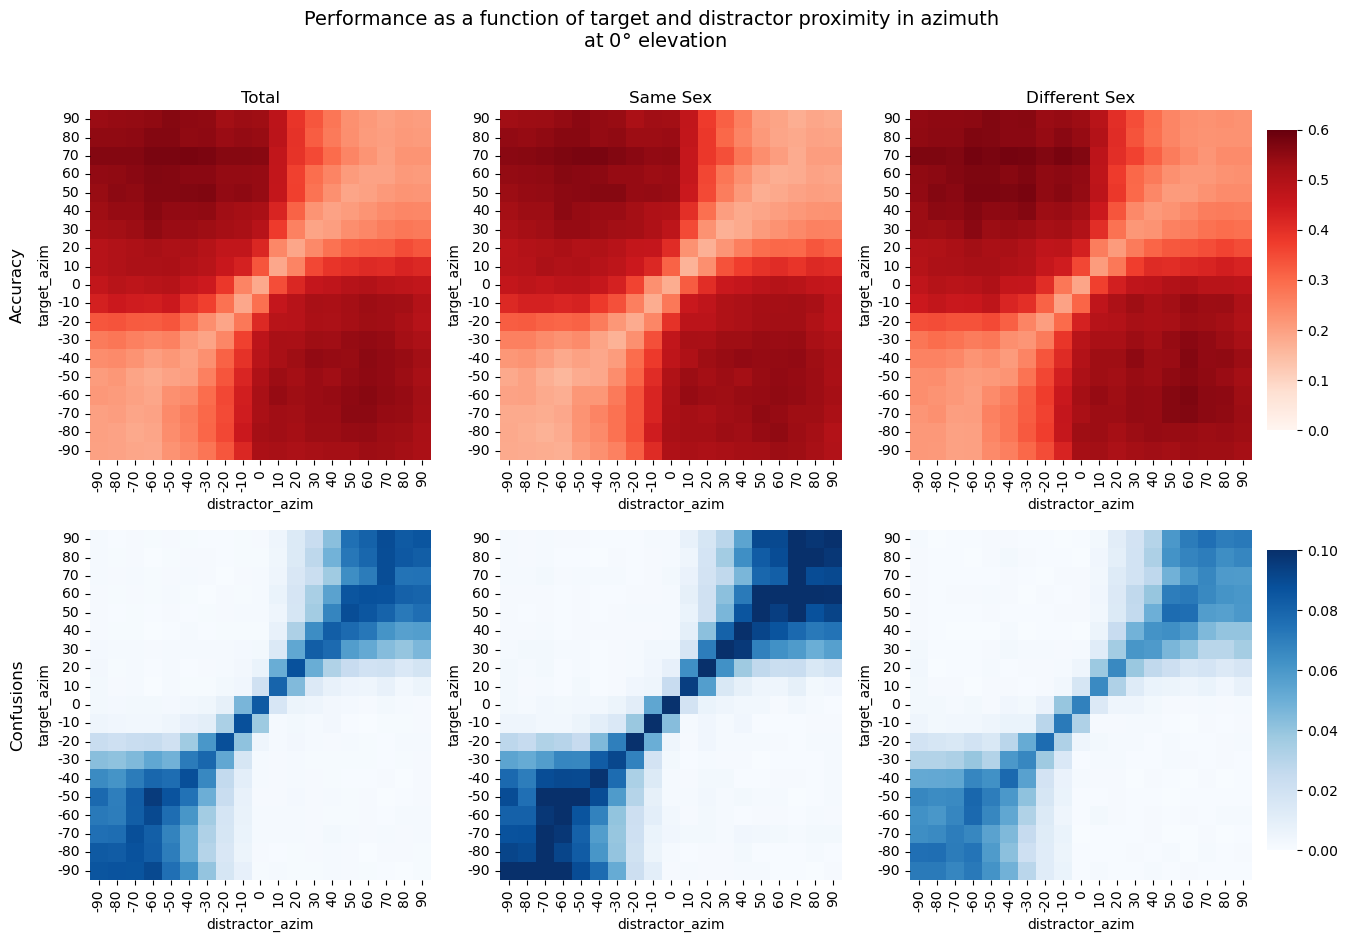

In [36]:
# plot all plots so far onto one figure
cols = ['Total', 'Same Sex', 'Different Sex']
rows = ['Accuracy', 'Confusions']

fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=False, sharey=False)

cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

total_acc = results.groupby(["target_azim", "distractor_azim"]).mean()['word_acc']
sns.heatmap(total_acc.unstack(), vmin=0, vmax=0.6, cmap='Reds', cbar=True, cbar_ax=cbar_ax_1, ax=axs[0, 0])
total_con = results.groupby(['target_azim', 'distractor_azim']).mean()['confusions']
sns.heatmap(total_con.unstack(), vmin=0, vmax=0.1, cmap='Blues', cbar=True, cbar_ax=cbar_ax_2, ax=axs[1, 0])

same_sex = results[results.sex_cond == 'same']
same_sex_acc = same_sex.groupby(['target_azim', 'distractor_azim'])['word_acc'].mean()
sns.heatmap(same_sex_acc.unstack(), vmin=0, vmax= 0.6, cmap='Reds', cbar=False, cbar_ax=None, ax=axs[0, 1])
same_sex_con = same_sex.groupby(['target_azim', 'distractor_azim'])['confusions'].mean()
sns.heatmap(same_sex_con.unstack(), vmin=0, vmax=0.1, cmap='Blues', cbar=False, cbar_ax=None, ax=axs[1, 1])

diff_sex = results[results.sex_cond == 'diff']
diff_sex_acc = diff_sex.groupby(['target_azim', 'distractor_azim'])['word_acc'].mean()
sns.heatmap(diff_sex_acc.unstack(), vmin=0, vmax=0.6, cmap='Reds', cbar=False, cbar_ax=None, ax=axs[0, 2])
diff_sex_con = diff_sex.groupby(['target_azim', 'distractor_azim'])['confusions'].mean()
sns.heatmap(diff_sex_con.unstack(), vmin=0, vmax=0.1, cmap='Blues', cbar=False, cbar_ax=None, ax=axs[1, 2])

for ax, col in zip(axs[0], cols):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
for ax, row in zip(axs[:, 0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# fig.tight_layout(rect=[0,0,.9,1])
plt.suptitle('Performance as a function of target and distractor proximity in azimuth\n at $0\degree$ elevation', fontsize=14, y=0.98);

for ax in axs.flatten():
    ax.invert_yaxis()


In [34]:
total_acc.max()

0.5785804816223067

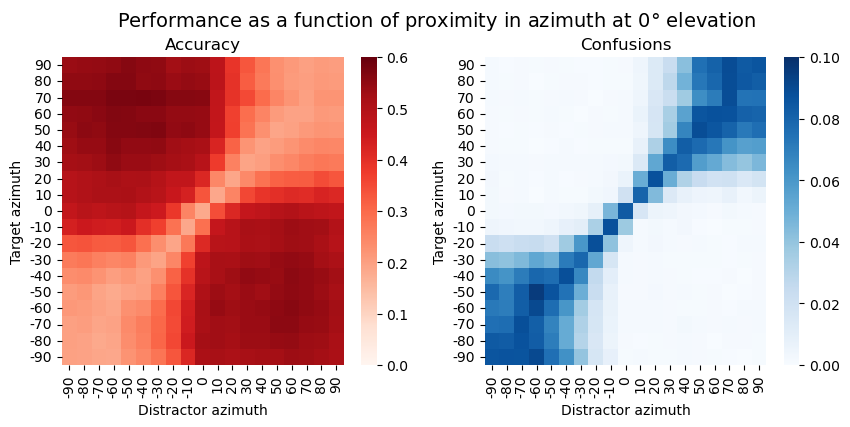

In [37]:
# New results using updated checkpoint epoch=0-step=2000-v2.ckpt

# plot all plots so far onto one figure
cols = ['Total', 'Same Sex', 'Different Sex']
rows = ['Accuracy', 'Confusions']

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharex=False, sharey=False)

# cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
# cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

total_acc = results.groupby(["target_azim", "distractor_azim"]).mean()['word_acc']
sns.heatmap(total_acc.unstack(), vmin=0, vmax=0.6, cmap='Reds', cbar=True,  ax=axs[0])

total_con = results.groupby(['target_azim', 'distractor_azim']).mean()['confusions']
sns.heatmap(total_con.unstack(), vmin=0, vmax=0.1, cmap='Blues', cbar=True,ax=axs[1])

# for ax, col in zip(axs[0], cols):
#     ax.annotate(col, xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# for ax, row in zip(axs[:, 0], rows):
#     ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# fig.tight_layout(rect=[0,0,.9,1])

axs[0].set_title("Accuracy", )#xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# for ax, row in zip(axs[1], rows):
axs[1].set_title("Confusions")
axs[0].set_ylabel("Target azimuth")
axs[1].set_ylabel("Target azimuth")
axs[0].set_xlabel("Distractor azimuth")
axs[1].set_xlabel("Distractor azimuth")


plt.suptitle('Performance as a function of proximity in azimuth at $0\degree$ elevation', fontsize=14, y=1);

for ax in axs.flatten():
    ax.invert_yaxis()


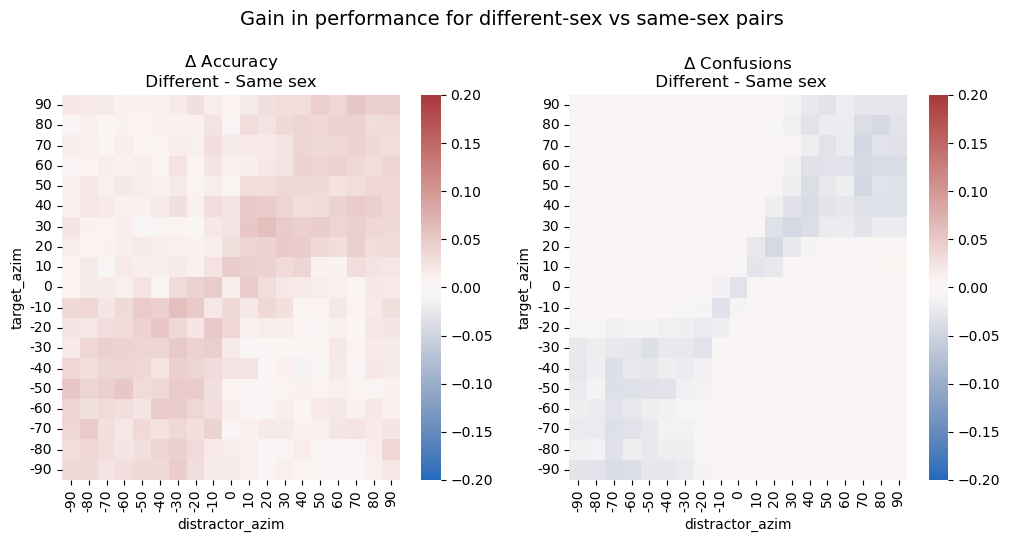

In [27]:
# plot all plots so far onto one figure
# cols = ['Total', 'Same Sex', 'Different Sex']
# rows = ['word_acc', 'Confusions']

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

# cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
# cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

diff_sex = results[results.sex_cond == 'diff']
same_sex = results[results.sex_cond == 'same']

diff = diff_sex.groupby(["target_azim", "distractor_azim"])['word_acc'].mean() - same_sex.groupby(["target_azim", "distractor_azim"])['word_acc'].mean()
sns.heatmap(diff.unstack(), vmin=-0.2, vmax=0.2, cmap='vlag', cbar=True, ax=axs[0]) #  cbar_ax=cbar_ax_1,

diff = diff_sex.groupby(["target_azim", "distractor_azim"])['confusions'].mean() - same_sex.groupby(["target_azim", "distractor_azim"])['confusions'].mean()
sns.heatmap(diff.unstack(), vmin=-0.2, vmax=0.2, cmap='vlag', cbar=True,  ax=axs[1]) # cbar_ax=cbar_ax_2,

# for ax, col in zip(axs[0], cols):
axs[0].set_title("$\Delta$ Accuracy \n Different - Same sex ", )#xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# for ax, row in zip(axs[1], rows):
axs[1].set_title("$\Delta$ Confusions \n Different - Same sex") # , xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# fig.tight_layout(rect=[0,0,.9,1])
plt.suptitle('Gain in performance for different-sex vs same-sex pairs', fontsize=14, y=1.05);

for ax in axs.flatten():
    ax.invert_yaxis()

In [28]:
## Plot for target at 00 

center_target_cond = results[results.target_azim == 0].reset_index(drop=True)

Text(0.5, 0, 'Distractor Azimuth')

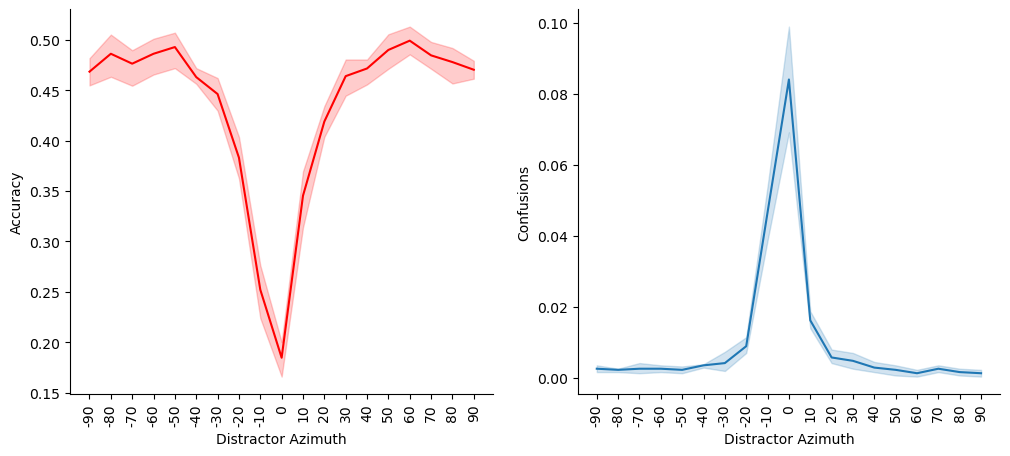

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)
sns.lineplot(data=center_target_cond, x='distractor_azim', y='word_acc', ax=axs[0], color='red') 
sns.lineplot(data=center_target_cond, x='distractor_azim', y='confusions', ax=axs[1])
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# make x ticks go -90 to 90
axs[0].set_xticks(np.arange(-90, 91, 10),np.arange(-90, 91, 10),rotation=90)
axs[1].set_xticks(np.arange(-90, 91, 10), np.arange(-90, 91, 10),rotation=90)
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
axs[0].set_xlabel("Distractor Azimuth")
axs[1].set_xlabel("Distractor Azimuth")




Text(0.5, 0, 'Distractor Azimuth')

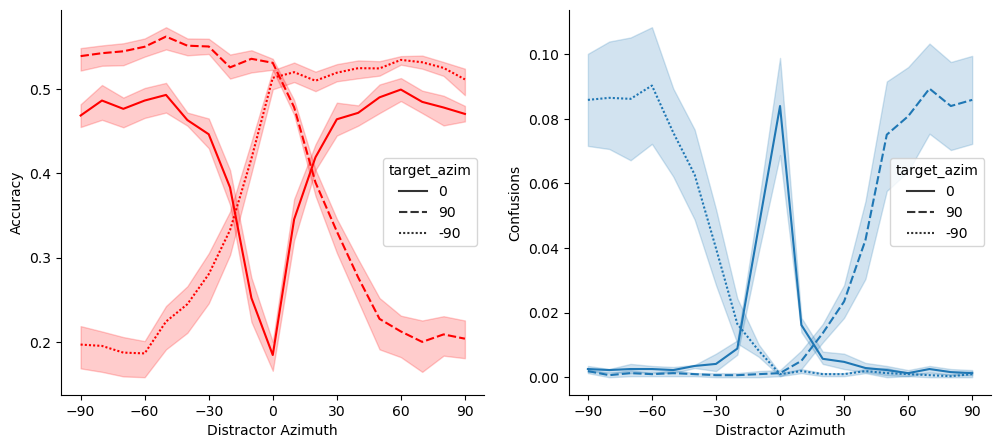

In [30]:
style_order = [0, 90, -90]
to_plot = results[results.target_azim.isin(style_order)].reset_index(drop=True)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)
sns.lineplot(data=to_plot, x='distractor_azim', y='word_acc', ax=axs[0], style='target_azim', style_order=style_order, color='red') 
sns.lineplot(data=to_plot, x='distractor_azim', y='confusions', style='target_azim', style_order=style_order, ax=axs[1])
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# make x ticks go -90 to 90
axs[0].set_xticks(np.arange(-90, 91, 30))
axs[1].set_xticks(np.arange(-90, 91, 30))
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
axs[0].set_xlabel("Distractor Azimuth")
axs[1].set_xlabel("Distractor Azimuth")


